In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

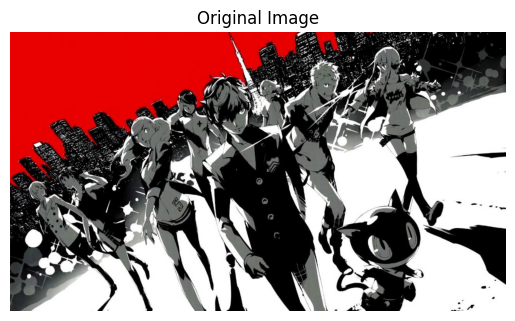

In [2]:
image_path = r"D:\Anaconda\persona.jpg"

img = Image.open(image_path).convert("RGB")

img_array = np.array(img)

plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [3]:
h, w, c = img_array.shape

pixels = img_array.reshape(-1,3)

print("Pixel dataset shape:", pixels.shape)

Pixel dataset shape: (1440000, 3)


In [4]:
def kmeans_manual(X, k, max_iters=20):

    # random centroids
    np.random.seed(0)
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):

        # distance calculation
        distances = np.linalg.norm(X[:,None] - centroids, axis=2)

        # cluster assignment
        labels = np.argmin(distances, axis=1)

        # update centroids
        new_centroids = np.array([X[labels==i].mean(axis=0) if len(X[labels==i])>0 else centroids[i] for i in range(k)])

        centroids = new_centroids

    return centroids, labels

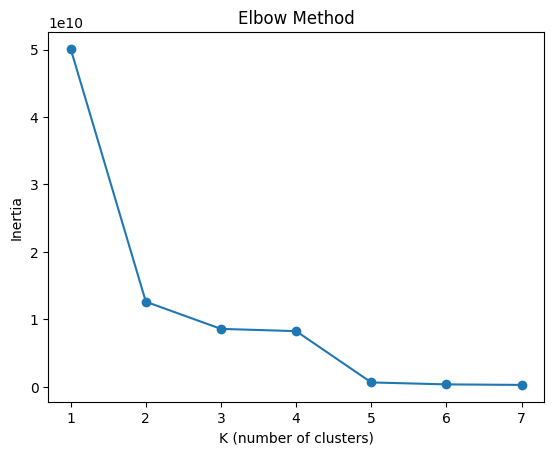

In [5]:
inertia = []
K_range = range(1,8)

for k in K_range:

    centroids, labels = kmeans_manual(pixels, k)

    # inertia calculation
    dist = np.linalg.norm(pixels - centroids[labels], axis=1)**2
    inertia.append(np.sum(dist))

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K (number of clusters)")
plt.ylabel("Inertia")
plt.show()

In [6]:
K = 3

centroids, labels = kmeans_manual(pixels, K)

In [7]:
segmented_pixels = centroids[labels]

segmented_pixels = segmented_pixels.astype(np.uint8)

segmented_image = segmented_pixels.reshape(h,w,3)

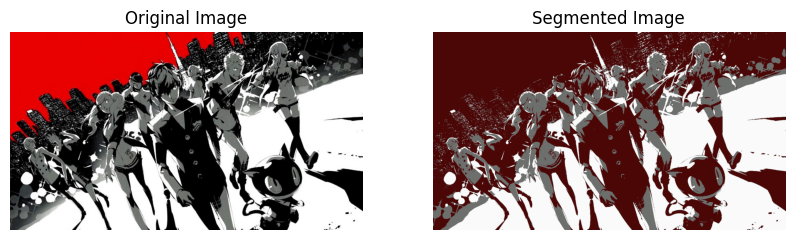

In [8]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented_image)
plt.title("Segmented Image")
plt.axis("off")

plt.show()

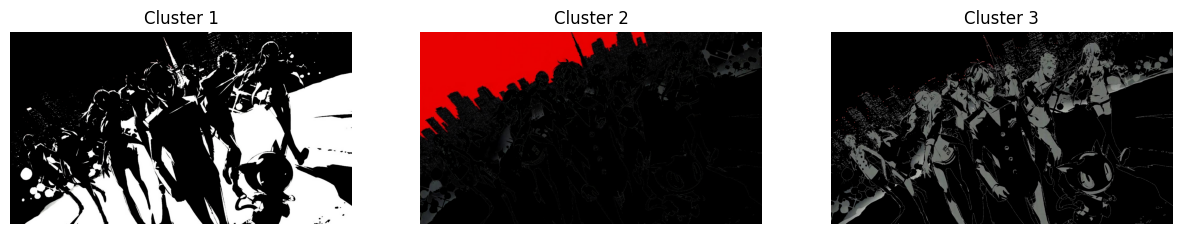

In [9]:
plt.figure(figsize=(15,5))

for i in range(K):

    cluster = pixels.copy()

    cluster[labels != i] = [0,0,0]

    cluster_img = cluster.reshape(h,w,3)

    plt.subplot(1,K,i+1)
    plt.imshow(cluster_img)
    plt.title(f"Cluster {i+1}")
    plt.axis("off")

plt.show()